# LLM-as-Judge — System Accuracy Evaluation
Send multiple audit requests to the `/audit/full` endpoint with different job roles,
then compute an **overall accuracy score** from the judge's system scores.

## 1. Setup & Request Bodies

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import json

PROGRESS_FILE = "audit_progress.json"

# Load already processed samples
processed_roles = []

if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, "r", encoding="utf-8") as f:
        processed_roles = json.load(f)

print(f"Already processed: {len(processed_roles)} samples") 

# Judge service URL (must be running on port 8005)
JUDGE_URL = "http://127.0.0.1:8005/audit/full"

# Mix of job roles — 7 roles x 15 questions = 105 total
request_bodies = [
    {"job_title": "Software Engineer",     "skills": ["Python", "OOP", "Data Structures"],        "experience_level": "Mid",    "num_questions": 15},
    {"job_title": "Backend Developer",     "skills": ["Node.js", "REST APIs", "Databases"],       "experience_level": "Mid",    "num_questions": 15},
    {"job_title": "Frontend Developer",    "skills": ["React", "JavaScript", "CSS"],              "experience_level": "Junior", "num_questions": 15},
    {"job_title": "DevOps Engineer",       "skills": ["Docker", "CI/CD", "AWS"],                  "experience_level": "Junior", "num_questions": 15},
    {"job_title": "System Architect",      "skills": ["System Design", "Microservices", "Cloud"], "experience_level": "Senior", "num_questions": 15},
    {"job_title": "Android Developer",     "skills": ["Kotlin", "Jetpack Compose", "Android SDK"],"experience_level": "Senior", "num_questions": 15},
    {"job_title": "Data Scientist",          "skills": ["Python", "Machine Learning", "Statistics"],       "experience_level": "Mid",    "num_questions": 15},
    {"job_title": "Cybersecurity Analyst",   "skills": ["Network Security", "Penetration Testing", "SIEM"],"experience_level": "Senior", "num_questions": 15},
    {"job_title": "Machine Learning Engineer", "skills": ["Python", "TensorFlow", "Deep Learning"],         "experience_level": "Mid",    "num_questions": 15},
    {"job_title": "Cloud Architect",           "skills": ["AWS", "Terraform", "Kubernetes"],                 "experience_level": "Senior", "num_questions": 15},
    {"job_title": "QA Tester",            "skills": ["Selenium", "Manual Testing", "Test Cases"],     "experience_level": "Junior", "num_questions": 15},
    {"job_title": "Mobile Developer",     "skills": ["Flutter", "Dart", "REST APIs"],                 "experience_level": "Junior", "num_questions": 15},
]

total_questions = sum(r["num_questions"] for r in request_bodies)
print(f"Total questions to generate & judge: {total_questions}")
print(f"Number of job roles: {len(request_bodies)}")


Already processed: 12 samples
Total questions to generate & judge: 180
Number of job roles: 12


## 2. Run the Audit Pipeline

In [3]:
import json as _json
from pathlib import Path as _Path

PROGRESS_FILE = _Path("audit_progress.json")

# Load any previously saved results
if PROGRESS_FILE.exists():
    all_results = _json.loads(PROGRESS_FILE.read_text(encoding="utf-8"))
    print(f"Loaded {len(all_results)} previously completed role(s) from {PROGRESS_FILE}")
else:
    all_results = []

completed_roles = {r["job_role"] for r in all_results}

for i, req in enumerate(request_bodies, 1):
    role = req["job_title"]

    # Skip already-completed roles
    if role in completed_roles:
        print(f"\n[{i}/{len(request_bodies)}] SKIPPED (already done): {role}")
        continue

    print(f"\n[{i}/{len(request_bodies)}] Auditing: {role} ({req['num_questions']} questions, {req['experience_level']})")

    start = time.time()
    try:
        response = requests.post(JUDGE_URL, json=req, timeout=600)
        response.raise_for_status()
        data = response.json()
        elapsed = round(time.time() - start, 1)
        print(f"    Done in {elapsed}s | System Score: {data['system_overall_score']}/10")

        all_results.append({
            "job_role": role,
            "experience_level": req["experience_level"],
            "num_questions": req["num_questions"],
            "avg_relevance": data["question_generation"]["average_relevance"],
            "avg_clarity": data["question_generation"]["average_clarity"],
            "avg_difficulty_calibration": data["question_generation"]["average_difficulty_calibration"],
            "question_score": data["question_generation"]["overall_score"],
            "avg_correctness": data["answer_generation"]["average_correctness"],
            "avg_completeness": data["answer_generation"]["average_completeness"],
            "avg_alignment": data["answer_generation"]["average_alignment"],
            "answer_score": data["answer_generation"]["overall_score"],
            "avg_faithfulness": data["evaluation_fairness"]["average_faithfulness"],
            "avg_judge_score": data["evaluation_fairness"]["average_judge_score"],
            "bias_count": data["evaluation_fairness"]["bias_count"],
            "evaluation_score": data["evaluation_fairness"]["overall_score"],
            "consistency": data["consistency"],
            "fluency": data["fluency"],
            "helpfulness": data["helpfulness"],
            "system_overall_score": data["system_overall_score"],
        })

        # Save progress after each successful role
        PROGRESS_FILE.write_text(_json.dumps(all_results, indent=2), encoding="utf-8")
        print(f"    Progress saved ({len(all_results)}/{len(request_bodies)} roles)")

    except Exception as e:
        print(f"    ERROR: {e}")
        print(f"    Progress saved so far: {len(all_results)} roles. Re-run this cell to resume.")
        break  # Stop on error so user can re-run to resume

    time.sleep(60)

print(f"\nDone! Successfully audited {len(all_results)}/{len(request_bodies)} roles.")
if len(all_results) == len(request_bodies):
    print("All roles complete! You can now run the analysis cells below.")


Loaded 12 previously completed role(s) from audit_progress.json

[1/12] SKIPPED (already done): Software Engineer

[2/12] SKIPPED (already done): Backend Developer

[3/12] SKIPPED (already done): Frontend Developer

[4/12] SKIPPED (already done): DevOps Engineer

[5/12] SKIPPED (already done): System Architect

[6/12] SKIPPED (already done): Android Developer

[7/12] SKIPPED (already done): Data Scientist

[8/12] SKIPPED (already done): Cybersecurity Analyst

[9/12] SKIPPED (already done): Machine Learning Engineer

[10/12] SKIPPED (already done): Cloud Architect

[11/12] SKIPPED (already done): QA Tester

[12/12] SKIPPED (already done): Mobile Developer

Done! Successfully audited 12/12 roles.
All roles complete! You can now run the analysis cells below.


## 3. Results DataFrame

In [4]:
df = pd.DataFrame(all_results)
print(f"Total roles audited: {len(df)}\n")
df

Total roles audited: 12



,job_role,experience_level,num_questions,avg_relevance,avg_clarity,avg_difficulty_calibration,question_score,avg_correctness,avg_completeness,avg_alignment,answer_score,avg_faithfulness,avg_judge_score,bias_count,evaluation_score,consistency,fluency,helpfulness,system_overall_score
0,Software Engineer,Mid,15,8.40,9.17,7.43,8.33,9.50,7.43,9.53,8.82,8.83,8.13,0,8.48,8.5,9.0,8.0,8.52
1,Backend Developer,Mid,15,8.23,9.00,7.07,8.10,9.67,8.20,9.67,9.18,8.87,8.43,0,8.65,8.5,9.0,8.0,8.57
2,Frontend Developer,Junior,15,8.23,9.10,7.13,8.16,9.40,8.00,9.40,8.93,8.63,7.73,0,8.18,8.5,9.0,8.0,8.46
3,DevOps Engineer,Junior,15,8.07,9.03,7.00,8.03,9.27,7.87,9.40,8.84,8.80,8.43,0,8.62,8.5,9.0,8.0,8.50
4,System Architect,Senior,15,8.70,9.10,7.83,8.54,9.57,8.53,9.63,9.24,8.73,7.65,0,8.19,8.5,9.0,8.0,8.58
5,Android Developer,Senior,15,8.70,9.03,7.57,8.43,9.60,8.57,9.63,9.27,8.57,6.40,0,7.48,8.5,9.0,8.0,8.45
6,Data Scientist,Mid,15,8.60,9.10,7.50,8.40,9.30,7.77,9.33,8.80,8.62,7.97,0,8.29,8.5,9.0,8.0,8.50
7,Cybersecurity Analyst,Senior,15,8.70,9.03,7.50,8.41,9.20,8.22,9.53,8.98,8.40,6.80,0,7.60,8.5,9.0,8.0,8.42
8,Machine Learning Engineer,Mid,15,8.77,9.30,7.73,8.60,9.47,8.33,9.47,9.09,8.73,8.23,0,8.48,8.5,9.0,8.0,8.61
9,Cloud Architect,Senior,15,8.57,9.17,7.67,8.47,9.57,8.39,9.53,9.16,8.53,7.17,0,7.85,8.5,9.0,8.0,8.50


## 4. Overall Accuracy

In [ ]:
# Convert 0-10 scale to 0-1 (percentage/accuracy)
df["accuracy"] = df["system_overall_score"] / 10

# Weighted mean (by number of questions per role)
weighted_accuracy = (df["accuracy"] * df["num_questions"]).sum() / df["num_questions"].sum()

# Simple mean
simple_mean_accuracy = df["accuracy"].mean()

print("=" * 55)
print(f"  Overall Accuracy (weighted): {weighted_accuracy:.4f}  ({weighted_accuracy*100:.2f}%)")
print(f"  Overall Accuracy (simple mean): {simple_mean_accuracy:.4f}  ({simple_mean_accuracy*100:.2f}%)")
print("=" * 55)
print(f"\n  Mean System Score:     {df['system_overall_score'].mean():.2f}/10")
print(f"  Mean Question Score:   {df['question_score'].mean():.2f}/10")
print(f"  Mean Answer Score:     {df['answer_score'].mean():.2f}/10")
print(f"  Mean Evaluation Score: {df['evaluation_score'].mean():.2f}/10")
print(f"  Total Bias Detected:   {df['bias_count'].sum()}")

  Overall Accuracy (weighted):    0.8502  (85.02%)
  Overall Accuracy (simple mean): 0.8502  (85.02%)

  Mean System Score:     8.50/10
  Mean Question Score:   8.31/10
  Mean Answer Score:     8.99/10
  Mean Evaluation Score: 8.20/10
  Total Bias Detected:   0


In [12]:
# Calculate new overall system score based on the equation
df["weighted_system_overall_score"] = (
    0.25 * df["question_score"] + 
    0.30 * df["answer_score"] + 
    0.20 * df["avg_correctness"] + 
    0.15 * df["avg_alignment"] + 
    0.10 * df["avg_clarity"]
)
final_accuracy = df["weighted_system_overall_score"].mean()
print("Final System Accuracy:", final_accuracy)
print("Final System Accuracy (%):", final_accuracy * 10)

Final System Accuracy: 8.981333333333334
Final System Accuracy (%): 89.81333333333333


## 5. Visualization

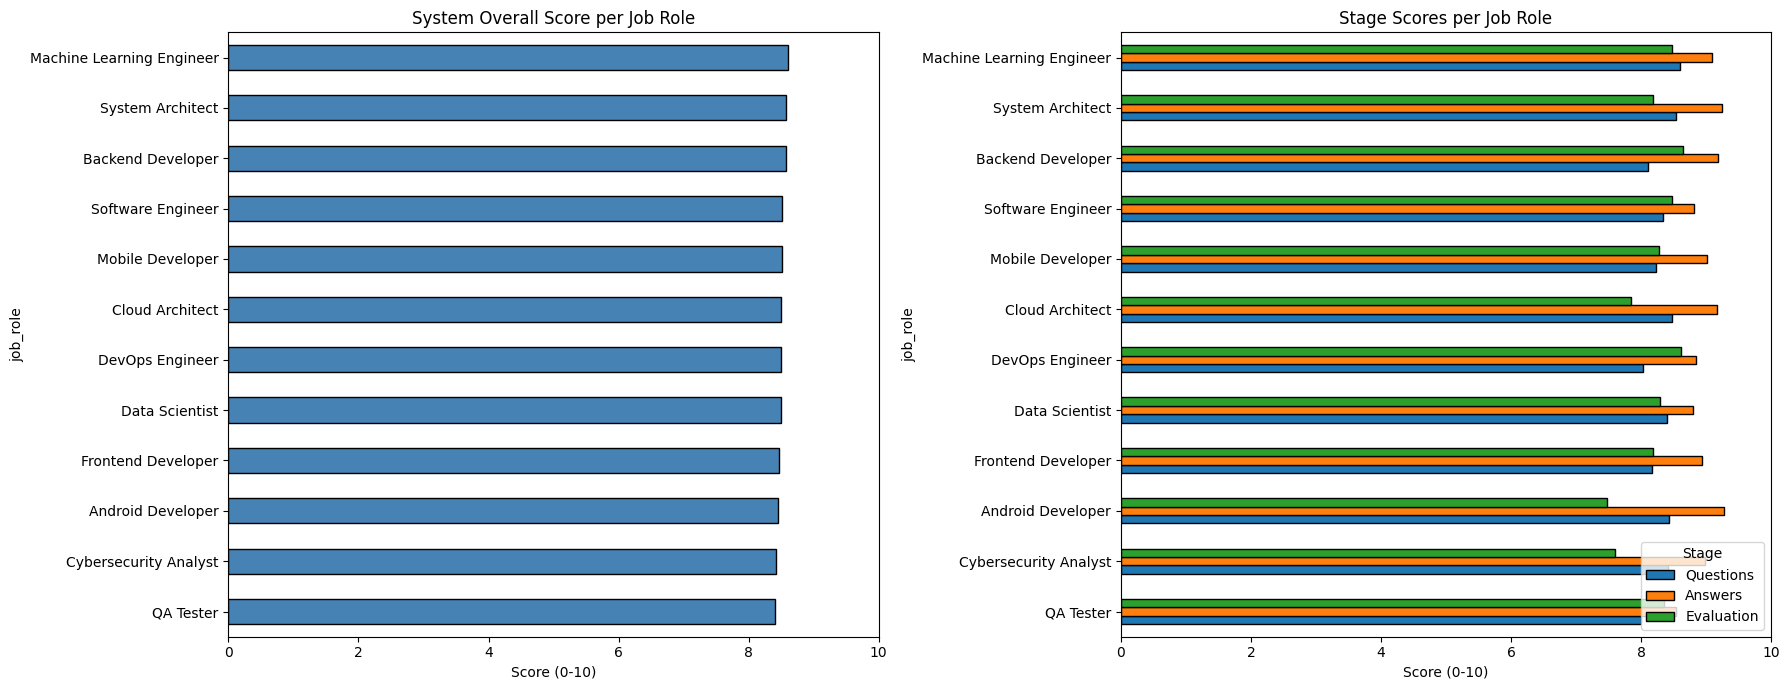

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart: System score per role
df_sorted = df.sort_values("system_overall_score", ascending=True)
df_sorted.plot(
    x="job_role", y="system_overall_score", kind="barh", ax=axes[0],
    legend=False, edgecolor="black", color="steelblue"
)
axes[0].set_title("System Overall Score per Job Role")
axes[0].set_xlabel("Score (0-10)")
axes[0].set_xlim(0, 10)

# Grouped bar: Stage scores per role
score_cols = ["question_score", "answer_score", "evaluation_score"]
df_sorted.plot(
    x="job_role", y=score_cols, kind="barh", ax=axes[1], edgecolor="black"
)
axes[1].set_title("Stage Scores per Job Role")
axes[1].set_xlabel("Score (0-10)")
axes[1].set_xlim(0, 10)
axes[1].legend(["Questions", "Answers", "Evaluation"], title="Stage")

plt.tight_layout()
plt.show()

## 6. Detailed Breakdown

In [7]:
detail_cols = [
    "job_role", "experience_level",
    "avg_relevance", "avg_clarity", "avg_difficulty_calibration",
    "avg_correctness", "avg_completeness", "avg_alignment",
    "avg_faithfulness", "bias_count",
    "consistency", "fluency", "helpfulness",
    "system_overall_score"
]
print("Detailed Breakdown:\n")
df[detail_cols].sort_values("system_overall_score", ascending=False)

Detailed Breakdown:



,job_role,experience_level,avg_relevance,avg_clarity,avg_difficulty_calibration,avg_correctness,avg_completeness,avg_alignment,avg_faithfulness,bias_count,consistency,fluency,helpfulness,system_overall_score
8,Machine Learning Engineer,Mid,8.77,9.30,7.73,9.47,8.33,9.47,8.73,0,8.5,9.0,8.0,8.61
4,System Architect,Senior,8.70,9.10,7.83,9.57,8.53,9.63,8.73,0,8.5,9.0,8.0,8.58
1,Backend Developer,Mid,8.23,9.00,7.07,9.67,8.20,9.67,8.87,0,8.5,9.0,8.0,8.57
0,Software Engineer,Mid,8.40,9.17,7.43,9.50,7.43,9.53,8.83,0,8.5,9.0,8.0,8.52
11,Mobile Developer,Junior,8.30,9.13,7.27,9.47,8.20,9.40,8.80,0,8.5,9.0,8.0,8.51
3,DevOps Engineer,Junior,8.07,9.03,7.00,9.27,7.87,9.40,8.80,0,8.5,9.0,8.0,8.50
9,Cloud Architect,Senior,8.57,9.17,7.67,9.57,8.39,9.53,8.53,0,8.5,9.0,8.0,8.50
6,Data Scientist,Mid,8.60,9.10,7.50,9.30,7.77,9.33,8.62,0,8.5,9.0,8.0,8.50
2,Frontend Developer,Junior,8.23,9.10,7.13,9.40,8.00,9.40,8.63,0,8.5,9.0,8.0,8.46
5,Android Developer,Senior,8.70,9.03,7.57,9.60,8.57,9.63,8.57,0,8.5,9.0,8.0,8.45
